Assignment 5: 

Name: **Ashutosh Reddy Atimyala**

UID: **118442129**

Please submit to ELMS
- a PDF containing all outputs (by executing **Run all**)
- your ipynb notebook containing all the code

I understand the policy on academic integraty (collaboration and the use of online material).
Please sign your name here: **Ashutosh Reddy Atimyala**

In [ ]:
# import the necessary packages
import numpy as np
import gzip, os
from urllib.request import urlretrieve
from random import random
from math import exp
from random import seed
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from statistics import mean
import torchvision.models as models

# Part 1: Backpropagation in Neural Networks (20 Points)

#### Overview
Artificial Neural Networks are computational learning systems that uses a network of functions to understand and translate a data input of one form into a desired output, usually in another form. The concept of the artificial neural network was inspired by human biology and the way neurons of the human brain function together to understand inputs from human senses.

A simple neural network consists of Input Layer, Hidden Layer and Output Layer.
To train these the network, we will use Backpropagation algorithm.  Backpropagation is the cornerstone of modern neural networks. To understand the algorithm in details, here is a mathematical description in the Chapter 2 of *How the backpropagation algorithm works from Neural Networks and Deep Learning* (http://neuralnetworksanddeeplearning.com/chap2.html).

In this part, you are required to implement the following architecture and write training code of a neural network from scratch using the numpy library alone. 

Architecture Definition :

*   An Input Layer with the following 2-dimensions:
  *  0: Batch Size
  *  1: 784 = 28*28 pixels
* A hidden layer with 500 units
* A second hidden layer with 50 units
* An output layer with 10 units

There are five major steps to the implementation:

1. Define neural network: initialize_network()

2. Forward Propagation: pre_activation(), sigmoid_activation(), forward_propagation()

3. Backpropagation: backward_propagate_error()

4. Loss function and updation of weights (SGD): update_weights()

5. Training: train()


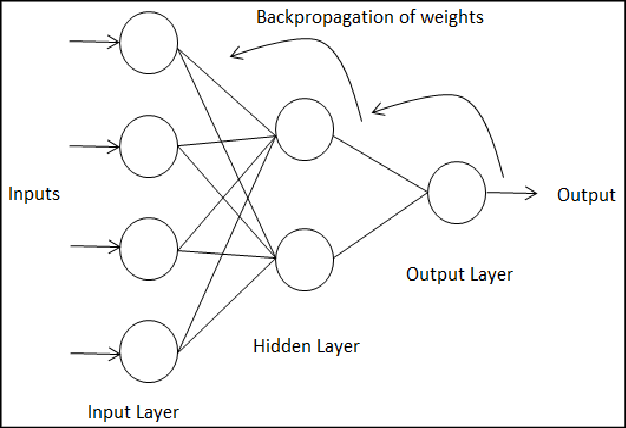



## Data

In [ ]:
# Download Data -- run this cell only one time per runtime
!gdown 11SpETIc56PReKuaUKEwWDvdkiynyyGFA
!unzip "/content/MNISTArchive.zip" -d "/content/"
!gzip -d "/content/t10k-labels-idx1-ubyte.gz"
!gzip -d "/content/t10k-images-idx3-ubyte.gz" 
!gzip -d "/content/train-labels-idx1-ubyte.gz"
!gzip -d "/content/train-images-idx3-ubyte.gz"

## Helper Functions:

### Code (10 pts)

In [ ]:
def read_mnist(path=None):
    r"""Return (train_images, train_labels, test_images, test_labels).

    Args:
        path (str): Directory containing MNIST. Default is
            /home/USER/data/mnist or C:\Users\USER\data\mnist.
            Create if nonexistant. Download any missing files.

    Returns:
        Tuple of (train_images, train_labels, test_images, test_labels), each
            a matrix. Rows are examples. Columns of images are pixel values.
            Columns of labels are a onehot encoding of the correct class.
    """
    url = 'http://yann.lecun.com/exdb/mnist/'
    files = ['train-images-idx3-ubyte.gz',
             'train-labels-idx1-ubyte.gz',
             't10k-images-idx3-ubyte.gz',
             't10k-labels-idx1-ubyte.gz']

    if path is None:
        # Set path to /home/USER/data/mnist or C:\Users\USER\data\mnist
        path = os.path.join(os.path.expanduser('~'), 'data', 'mnist')

    # Create path if it doesn't exist
    os.makedirs(path, exist_ok=True)

    # Download any missing files
    for file in files:
        if file not in os.listdir(path):
            urlretrieve(url + file, os.path.join(path, file))
            print("Downloaded %s to %s" % (file, path))

    def _images(path):
        """Return images loaded locally."""
        with gzip.open(path) as f:
            # First 16 bytes are magic_number, n_imgs, n_rows, n_cols
            pixels = np.frombuffer(f.read(), 'B', offset=16)
        return pixels.reshape(-1, 784).astype('float32') / 255

    def _labels(path):
        """Return labels loaded locally."""
        with gzip.open(path) as f:
            # First 8 bytes are magic_number, n_labels
            integer_labels = np.frombuffer(f.read(), 'B', offset=8)

        def _onehot(integer_labels):
            """Return matrix whose rows are onehot encodings of integers."""
            n_rows = len(integer_labels)
            n_cols = integer_labels.max() + 1
            onehot = np.zeros((n_rows, n_cols), dtype='uint8')
            onehot[np.arange(n_rows), integer_labels] = 1
            return onehot

        return _onehot(integer_labels)

    train_images = _images(os.path.join(path, files[0]))
    train_labels = _labels(os.path.join(path, files[1]))
    test_images = _images(os.path.join(path, files[2]))
    test_labels = _labels(os.path.join(path, files[3]))

    return train_images, train_labels, test_images, test_labels

In [ ]:
# Initialize a network
def initialize_network(n_inputs, n_hidden, n_outputs):
	network = list()
	
	hidden_layer = None
	## Write your code. Initialize hidden layer here.
	hidden_layer = [{'weights' : [random() for i in range(n_inputs+1)]} for i in range(n_hidden)]
	network.append(hidden_layer)
 
	output_layer = None
	## Write your code. Initialize output_layer layer here. 
	output_layer = [{'weights' : [random() for i in range(n_hidden+1)]} for i in range(n_outputs)]
	network.append(output_layer)
	return network

In [ ]:
# Calculate neuron activation for an input
def pre_activation(weights, inputs):
	activation = weights[-1]
	for i in range(len(weights)-1):
		## Write code here. compute activation: Wx+b
		activation += weights[i] * inputs[i]
	return activation

def sigmoid_activation(activation):
	out_sigmoid=None
	## write code. implement sigmoid function
	out_sigmoid = 1.0 / (1.0 + np.exp(-activation))
	return out_sigmoid
 
# Calculate the derivative of a neuron output
def sigmoid_derivative(output):
	## write code. implement sigmoid function
	out_sigmoid_deriv = None
	# out_sigmoid_deriv = np.exp(-output)/ ((np.exp(-output) + 1)**2)
	out_sigmoid_deriv = (output * (1.0 - output))
	return out_sigmoid_deriv

In [ ]:
# Forward Propagation:
def forward_propagation(network, row):
	inputs = row
	for layer in network:

		new_inputs = []
		## write you code here.
		## for each hidden neuron this 'layer', compute \
		## pre_activation, sigmoid_activation and save then output in 'new_inputs.'
		for neuron in layer:
			activation = pre_activation(neuron['weights'],inputs)
			neuron['out_sigmoid'] = sigmoid_activation(activation)
			new_inputs.append(neuron['out_sigmoid'])
	 	
		inputs = new_inputs
	return inputs

# Backpropagation:
def backward_propagate_error(network, ground_truth):
	for i in reversed(range(len(network))):
		layer = network[i]
		errors = list()
		if i != len(network)-1:
			## write your code here.
			## compute error for all the hidden layer and append it to errors to keep track.
			for j in range(len(layer)):
				error = 0
				for neuron in network[i+1]:
					error += (neuron['weights'][j] * neuron['delta'])
				errors.append(error)
		else:
			## write your code here.
			## compute error for the output layer using ground_truth and append it to errors to keep track.
			for j in range(len(layer)):
				neuron = layer[j]
				errors.append(neuron['out_sigmoid'] - ground_truth[j])			
	 
		for j in range(len(layer)):
			neuron = layer[j]
			neuron['delta'] = errors[j] * sigmoid_derivative(neuron['out_sigmoid'])  
   
# Stochastic GD for weight updation:
def update_weights(network, row, l_rate):
	for i in range(len(network)):
		inputs = row[:-1]
		if i != 0:
			## write your code here.
			## pass activation i.e. neuron['output'] from previous layer as input to current layer 'i'
			inputs = [neuron['out_sigmoid'] for neuron in network[i-1]]
				
	 
		for neuron in network[i]:						
			for j in range(len(inputs)):
				## write you code here.
				## update the weights between each input and each neuron.
				neuron['weights'][j] -= neuron['delta'] * inputs[j] * l_rate
		
			## write you code here.
			## update the bias vector
			neuron['weights'][-1] -= neuron['delta'] * l_rate
	 
# Train a network for a fixed number of epochs
def train(network, train, l_rate, n_epoch, n_outputs):
	for epoch in range(n_epoch):
		sum_error = 0
		for row in train:
			outputs = forward_propagation(network, row)
			expected = [0 for i in range(n_outputs)]
			expected[row[-1]] = 1
			sum_error += sum([(expected[i]-outputs[i])**2 for i in range(len(expected))])
			backward_propagate_error(network, expected)
			update_weights(network, row, l_rate)
		print('>epoch=%d, lrate=%.3f, error=%.3f' % (epoch, l_rate, sum_error))      
	

In [ ]:
# 1. Test your code for backprop algorithm on this sample dataset.
seed(1)
sample_dataset = [[2.7810836,2.550537003,0],
	[1.465489372,2.362125076,0],
	[3.396561688,4.400293529,0],
	[1.38807019,1.850220317,0],
	[3.06407232,3.005305973,0],
	[7.627531214,2.759262235,1],
	[5.332441248,2.088626775,1],
	[6.922596716,1.77106367,1],
	[8.675418651,-0.242068655,1],
	[7.673756466,3.508563011,1]]

n_inputs = len(sample_dataset[0]) - 1
n_outputs = len(set([sample[-1] for sample in sample_dataset]))
network = initialize_network(n_inputs, 2, n_outputs)
train(network, sample_dataset, l_rate=0.5, n_epoch=50, n_outputs=n_outputs)
for layer in network:
	print(layer)

In [ ]:
# 2. Read MNIST data and test above algorithm on it.

# Read MNIST data
train_images, train_labels, test_images, test_labels = read_mnist(path='/content/')
print(train_images.shape, train_labels.shape)
sd=np.hstack((train_images,train_labels))
# Run Backpropagation.
# Write you code here.

n_inputs = len(sample_dataset[0]) - 1
n_outputs = len(set([sample[-1] for sample in sample_dataset]))
network = initialize_network(n_inputs, 10, n_outputs)

train(network, sd, l_rate=0.5, n_epoch=20, n_outputs=10)
for layer in network:
	print(layer)

### Write-up (10 pts)

1. You are required to report a) train error w.r.t epoch, b) train and test accuracy numbers on MNIST dataset at the end of training.
2. Experiment with different number of a) hidden layers b) training epochs and report the ablation study.

https://machinelearningmastery.com/implement-backpropagation-algorithm-scratch-python/

https://github.com/profthyagu/Python-ANN-Backpropagation/blob/master/4.ANN_BackPropogation.ipynb

https://gist.github.com/nickstenning/887946

https://github.com/dcavar/python-tutorial-notebooks/blob/master/notebooks/Backpropagation.ipynb

https://github.com/jariasf/CS231n/blob/master/assignment2/cs231n/layers.py

# Part 2: Training an Image Classifier




##Overview
CIFAR10 dataset will be used to train an image classifier.

![](https://miro.medium.com/max/578/1*BCsHErqOJxmKDLQXYJR_ow.png)



##Data
Using `torchvision`, it’s extremely easy to load `CIFAR10`.

In [ ]:
## The output of torchvision datasets are PILImage images of range [0, 1]. We transform them to Tensors of normalized range [-1, 1].
transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

batch_size = 4

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                          shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size,
                                         shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

In [ ]:
## Let us show some of the training images, for fun.

# functions to show an image
def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()


# get some random training images
dataiter = iter(trainloader)
images, labels = next(dataiter)

# show images
imshow(torchvision.utils.make_grid(images))
# print labels
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(batch_size)))

##Code (20 pts)

###Define a Convolutional Neural Network (10 pt)

Create a neural network that take 3-channel images. It should go as Conv2d --> ReLU --> MaxPool2d --> Conv2d --> ReLU --> MaxPool2d --> Flatten --> Linear --> ReLU --> Linear --> ReLU --> Linear

In [ ]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3,32,3,padding=1)
        self.pool = nn.MaxPool2d(2,2)
        self.conv2 = nn.Conv2d(32,16,3,padding=1)
        self.dp= nn.Dropout(p=0.25)
        self.fc1 = nn.Linear(16 * 8 * 8,128)
        self.fc2 = nn.Linear(128,64)
        self.fc3 = nn.Linear(64,32)
        self.fc4 = nn.Linear(32,16)
        self.fc5 = nn.Linear(16,10)

        ## TODO: Add layers to your neural net.

    def forward(self, x):
        ## TODO: run forward pass as mentioned above.
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x=  self.dp(x)
        x = x.view(-1,16 * 8 * 8)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        x = F.relu(self.fc4(x))
        x = self.fc5(x)
        return x


net = Net()

###Define a Loss function and optimizer (5 pt)

Let’s use a Classification Cross-Entropy loss and SGD with momentum. (Feel free to experiment with other loss functions and optimizers to observe differences)

In [ ]:
criterion = nn.CrossEntropyLoss() ## TODO: Add loss function
optimizer = optim.SGD(net.parameters(), lr=0.001,momentum=0.9) ## TODO: Add optimizer

###Train the network (5 pts)

This is when things start to get interesting. We simply have to loop over our data iterator, and feed the inputs to the network and optimize.

In [ ]:
epochs = 10 ## TODO: define number of epochs to train
train_losses = []
train_accuracy = []
for epoch in range(epochs):  # loop over the dataset multiple times

    running_loss = 0.0
    correct_values = 0.0
    total = 0.0
    for i, data in enumerate(trainloader, 0):
      
        # get the inputs; data is a list of [inputs, labels]
        inputs, labels = data

        # TODO: add line to zero the parameter gradients below
        optimizer.zero_grad()

        # forward + backward + optimize
        outputs = net(inputs)
        _, predictions = torch.max(outputs, 1)
        total += labels.size(0)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        correct_values += (predictions == labels).float().sum()
        # print statistics
        running_loss += loss.item()
        if i % 2000 == 1999:    # print every 2000 mini-batches
            print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 2000:.3f}')
            running_loss = 0.0
    train_accuracy.append((100 * correct_values) / total)
    train_losses.append(running_loss/(i+1))

print('Finished Training')

## Let’s quickly save our trained model:

PATH = './cifar_net.pth'
torch.save(net.state_dict(), PATH)

###Test the network on the test data
We have trained the network over the training dataset. But we need to check if the network has learnt anything at all.

We will check this by predicting the class label that the neural network outputs, and checking it against the ground-truth. If the prediction is correct, we add the sample to the list of correct predictions.


In [ ]:
from sklearn.metrics import confusion_matrix

# prepare to count predictions for each class
correct_pred = {classname: 0 for classname in classes}
total_pred = {classname: 0 for classname in classes}
correct = 0.0
total = 0.0
# again no gradients needed
y_true = []
y_pred = []
with torch.no_grad():
    for data in testloader:
        images, labels = data
        y_true.extend(labels.numpy())
        outputs = net(images)
        _, predictions = torch.max(outputs, 1)
        y_pred.extend(predictions.cpu().numpy())
        total += labels.size(0)
        correct += (predictions == labels).sum().item()
        # collect the correct predictions for each class
        for label, prediction in zip(labels, predictions):
            if label == prediction:
                correct_pred[classes[label]] += 1
            total_pred[classes[label]] += 1
    cf_matrix = confusion_matrix(y_true, y_pred)

print(f'Test Accuracy of the network on the 10000 test images: {100 * correct / total} %')
# print accuracy for each class
for classname, correct_count in correct_pred.items():
    accuracy = 100 * float(correct_count) / total_pred[classname]
    print(f'Accuracy for class: {classname:5s} is {accuracy:.1f} %')

In [ ]:
import seaborn as sn
import pandas as pd
plt.figure(figsize=(10,5))
plt.title("Training Loss vs Epochs")
plt.plot(np.arange(1,11),train_losses,label="train")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.figure(figsize=(10,5))
plt.title("Training Accuracy vs Epochs")
plt.plot(np.arange(1,11),train_accuracy,label="train")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

df_cm = pd.DataFrame(cf_matrix, index = [i for i in classes],
                     columns = [i for i in classes])
plt.figure(figsize = (12,7))
sn.heatmap(df_cm, annot=True)
plt.title("Confusion Matrix"), plt.tight_layout()
plt.ylabel("True Class"), 
plt.xlabel("Predicted Class")
plt.show()

## Write-up (5 pt)
(1 pt) Show plot for loss over epochs.

(1 pt) Show plot for accuracy over epochs.

(3 pt) Show confusion matrix on test data.

## Extra Credits (5 pt)
Run VGG with pre-trained weights in this [colab](https://colab.research.google.com/github/pytorch/pytorch.github.io/blob/master/assets/hub/pytorch_vision_vgg.ipynb#scrollTo=daily-wayne). Test any two images of your choice to your model and to VGG model and show accuracy (images must include objects from CIFAR10 classes). Discuss which model performs better and why.

# Part 3: Semantic Segmentation

## Overview
Semantic Segmentation is an image analysis task in which we classify each pixel in the image into a class.
So, let's say we have the following image.

![](https://lh3.googleusercontent.com/-ELUnFgFJqUU/XPPXOOmhfMI/AAAAAAAAAP0/2cabsTI9uGUYxM3O3w4EOxjR_iJvEQAvACK8BGAs/s374/index3.png)

And then given the above image its semantically segmentated image would be the following

![](https://lh3.googleusercontent.com/-gdUavPeOxdg/XPPXQngAnvI/AAAAAAAAAQA/yoksBterCGQGt-lv3aX4kfyMUDXTar7yACK8BGAs/s374/index4.png)

As you can see, that each pixel in the image is classified to its respective class.


## Data

**WARNING: Colab deletes all files everytime runtime is disconnected. Make sure to re-download the inputs when it happens.**

In [ ]:
import os 
import tarfile
import shutil
import urllib.request

url='http://host.robots.ox.ac.uk/pascal/VOC/voc2007/VOCtrainval_06-Nov-2007.tar'
path='VOC'
def get_archive(path,url):
  try:
    os.mkdir(path)
  except:
    path=path
  
  filename='devkit'
  urllib.request.urlretrieve(url,f"{path}/{filename}.tar")
 
get_archive(path,url)
def extract(path):
  tar_file=tarfile.open(f"{path}/devkit.tar")
  tar_file.extractall('./')
  tar_file.close()
  shutil.rmtree(path)

extract(path)

## Helper Functions

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt
import torch
from torchvision import models
import torchvision.transforms as T
import numpy as np

"""Various RGB palettes for coloring segmentation labels."""
VOC_CLASSES = [
    "background",
    "aeroplane",
    "bicycle",
    "bird",
    "boat",
    "bottle",
    "bus",
    "car",
    "cat",
    "chair",
    "cow",
    "diningtable",
    "dog",
    "horse",
    "motorbike",
    "person",
    "potted plant",
    "sheep",
    "sofa",
    "train",
    "tv/monitor",
]


VOC_COLORMAP = [
    [0, 0, 0],
    [128, 0, 0],
    [0, 128, 0],
    [128, 128, 0],
    [0, 0, 128],
    [128, 0, 128],
    [0, 128, 128],
    [128, 128, 128],
    [64, 0, 0],
    [192, 0, 0],
    [64, 128, 0],
    [192, 128, 0],
    [64, 0, 128],
    [192, 0, 128],
    [64, 128, 128],
    [192, 128, 128],
    [0, 64, 0],
    [128, 64, 0],
    [0, 192, 0],
    [128, 192, 0],
    [0, 64, 128],
]


if torch.cuda.is_available():
  device=torch.device('cuda:0')
  print('Cuda')
else:
  device=torch.device('cpu')
  print('cpu')

## Code (25 pt)

### 1. Implement Data Loader for training and validation (5 pt)

In [ ]:
import os 
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import cv2

# You can modify this class 
class VocDataset(Dataset):
  def __init__(self, dir, color_map):
    self.root=os.path.join(dir,'VOCdevkit/VOC2007')
    self.target_dir=os.path.join(self.root,'SegmentationClass')
    self.images_dir=os.path.join(self.root,'JPEGImages')
    file_list = os.path.join(self.root,'ImageSets/Segmentation/trainval.txt')
    self.files = [line.rstrip() for line in tuple(open(file_list, "r"))]
    self.color_map=color_map

  def convert_to_segmentation_mask(self,mask):
    # This function converts color channels of semgentation masks to number of classes
    # Semantic Segmentation requires a segmentation mask to be a NumPy array with the shape
    # This part is implemented for displaying colorized results in subpart 3
    # YOUR CODE HERE:
    height, width = mask.shape[:2]
    segmentation_mask = np.zeros((height, width, len(self.color_map)), dtype=np.float32)
    for label_index, label in enumerate(self.color_map):
          segmentation_mask[:, :, label_index] = np.all(mask == label, axis=-1).astype(float)
    return segmentation_mask

  def __getitem__(self,index):
    # YOUR CODE HERE:
    image_id=self.files[index]
    image_path=os.path.join(self.images_dir,f"{image_id}.jpg")
    label_path=os.path.join(self.target_dir,f"{image_id}.png")
    image=cv2.imread(image_path)
    image=cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
    image=cv2.resize(image,(256,256))
    image=torch.tensor(image).float()
    label=cv2.imread(label_path)
    label=cv2.cvtColor(label,cv2.COLOR_BGR2RGB)
    label=cv2.resize(label,(256,256))
    label = self.convert_to_segmentation_mask(label)
    label=torch.tensor(label).float()
    
    return image,label
    
  def __len__(self):
    return len(self.files)

# Load the dataset
dataset = VocDataset('',VOC_COLORMAP)
# Create a dataloader
dataloader = DataLoader(dataset, batch_size=4, shuffle=True, num_workers=0)

# Get a batch of training data
images, labels = next(iter(dataloader))

dataset.__len__()



# Train set and validation set 
train_set,val_set=torch.utils.data.random_split(dataset,[int(len(dataset)*0.9),round(len(dataset)*0.1)+1])
train_loader = DataLoader(train_set, batch_size=10, shuffle=True, num_workers=0)
val_loader = DataLoader(val_set, batch_size=10, shuffle=True, num_workers=0)
test_loader = DataLoader(dataset, batch_size=10, shuffle=True, num_workers=0)


###2. Define model and training code (15 pt)
Implement FCN-32 model. You can use encoder as pretrained model provided by torchvision.       

In [ ]:
import torch
class FCN32(torch.nn.Module):
  def __init__(self, n_classes, pretrained_model):
    # YOUR CODE HERE:
    super(FCN32, self).__init__()
    self.pretrained_model=pretrained_model
    # encoder
    self.encoder = torch.nn.Sequential(*list(pretrained_model.features.children()))

    self.encoder_classifier = torch.nn.Sequential(
        torch.nn.Conv2d(512, 4096, kernel_size=1),
        torch.nn.ReLU(inplace=True),
        torch.nn.Dropout(),
        torch.nn.Conv2d(4096, 4096, kernel_size=1),
        torch.nn.ReLU(inplace=True),
        torch.nn.Dropout()
    )

    # decoder
    self.decoder = torch.nn.Sequential(
        torch.nn.ConvTranspose2d(4096, 512, kernel_size=3, stride=2, padding=1, output_padding=1),
        torch.nn.BatchNorm2d(512),
        torch.nn.ReLU(inplace=True),
        torch.nn.ConvTranspose2d(512, 256, kernel_size=3, stride=2, padding=1, output_padding=1),
        torch.nn.BatchNorm2d(256),
        torch.nn.ReLU(inplace=True),
        torch.nn.ConvTranspose2d(256, 128, kernel_size=3, stride=2, padding=1, output_padding=1),
        torch.nn.BatchNorm2d(128),
        torch.nn.ReLU(inplace=True),
        torch.nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=1),
        torch.nn.BatchNorm2d(64),
        torch.nn.ReLU(inplace=True),
        torch.nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),
        torch.nn.BatchNorm2d(32),
        torch.nn.ReLU(inplace=True),
        torch.nn.Conv2d(32, n_classes, kernel_size=1)
    )

  # forward function
  def forward(self, x):
    # apply encoder
    output = self.encoder(x)
    output = self.encoder_classifier(output)

    # apply decoder
    output = self.decoder(output)

    # return the predicted label image
    return output

 Training code for the semantic segmentation model. Implment both training and validation parts.  

In [ ]:

import torchvision 
from torch.utils.data import Dataset, DataLoader, random_split
import tqdm
import sklearn.metrics
# import segmentation_models_pytorch as smp

def metrics(y_pred,y_true):
  y_pred=torch.argmax(y_pred,dim=1)
  y_true=torch.argmax(y_true,dim=1)
  iou=sklearn.metrics.jaccard_score(y_true.flatten(),y_pred.flatten(),average='weighted')
  return iou

def train(model,optim,loss_f,epochs,scheduler,path_for_models):
  try:
    os.mkdir(path_for_models)
  except:
    path_for_models=path_for_models

  min_iou=0.3
  device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
  for epoch in (range(epochs)):
    for (X_train,y_train) in train_loader:
      # X_train,y_train=X_train.to(device),y_train.to(device,dtype=torch.int64)
      X_train = X_train.permute(0, 3, 1, 2)
      y_train = y_train.permute(0, 3, 1, 2)
      y_pred=model(X_train)
      loss=loss_f(y_pred,y_train)

      optim.zero_grad()
      loss.backward()
      optim.step()
    ious=[]
    val_losses=[]
    with torch.no_grad():
      for b,(X_test,y_test) in enumerate(val_loader):
        X_test,y_test=X_test.to(device),y_test.to(device)
        X_test = X_test.permute(0, 3, 1, 2)
        y_test = y_test.permute(0, 3, 1, 2)
        y_val=model(X_test)
        val_loss=loss_f(y_val,y_test)
        val_losses.append(val_loss)
        iou_= metrics(y_val,y_test)
        ious.append(iou_)
      ious=torch.tensor(ious)
      val_losses=torch.tensor(val_losses)
      scheduler.step(val_losses.mean())
      if ious.mean() > min_iou:
        min_iou=ious.mean()
        torch.save(model.state_dict(),f"{path_for_models}/fc32model.pth")
    print(f"epoch : {epoch:2} train_loss: {loss:10.4} , val_loss : {val_losses.mean()} val_iou: {ious.mean()}")


pretrained_net = torchvision.models.vgg16(pretrained=True)

model = FCN32(n_classes=21, pretrained_model=pretrained_net)

criterion = torch.nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

scheduler=torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer,patience=3,verbose=True)

num_epochs = 10

train(model,optimizer,criterion,10,scheduler,'models')

### 3. Inference for semantic segmentation (5 pt)

Implement the inference code for semantic segmentation. Display the visualization results of each three model. Plot the image and colorized image (similar to the results in overview). 

In [ ]:
import imageio

def decode_segmap(image,colors,nc=21):
  r = np.zeros_like(image).astype(np.uint8)
  g = np.zeros_like(image).astype(np.uint8)
  b = np.zeros_like(image).astype(np.uint8)
  for l in range(0, nc):
    idx = image == l
    r[idx] = colors[l][0]
    g[idx] = colors[l][1]
    b[idx] = colors[l][2]
  rgb = np.stack([r, g, b], axis=2)
  return rgb
  
def image(img_path):
  img=cv2.imread(img_path,cv2.IMREAD_COLOR)
  img= torch.tensor(img)
  image = torch.argmax(img.squeeze(), dim=2).detach().cpu().numpy()
  plt.figure(figsize=(10, 10))
  plt.imshow(image)
  plt.axis('off')
  return image


image_list = ['000347','001707','001950']
for img in image_list:
  print(f'\nImage: {img}.jpg')
  plt.figure(figsize=(10, 10))
  plt.imshow(imageio.imread('./VOCdevkit/VOC2007/JPEGImages/'+img+'.jpg'))
  plt.axis('off')
  plt.show()

  rgb = decode_segmap(image('./VOCdevkit/VOC2007/JPEGImages/'+img+'.jpg'),VOC_COLORMAP)
  plt.figure(figsize=(10, 10))
  plt.imshow(rgb)
  plt.axis('off')
  plt.show()

## Write-up (5 pt)
* Describe the properties of segmentation model
* Describe the evaluation metric (IoU) for segmentation model 

## Write-up Answers:

**Properties of Segmentation Model**:  
The goal of semantic segmentation is to label each pixel of the input image with the respective class representing a specific object. A way to achieve segmentation is by Fully Convolutional Network(FCN), which stacks a number of convoluttional layers having similar padding to preserve dimension.
1. Convolution: The model contains many convolutional layers which extracts features from an input image of any size and returns a segmented map.
2. Pooling: Pooling reduces the resolution of convoluted features furthermore reducing computational requirements. This also helps in reduction of noise while extracting dominannt featues.
3. Upsampling: Upscales the resolution of the input image which helps the model to make more detailed predictions.
4. Skip Connections: Downsampling in a FCN reduces the resolution,and upsampling it becomes hard to generate details. Thus, skip connections provide enough information to the layers to produce segmentation boundaries more accurately or accurate spatial structure.


**Evaluation Metric(IOU) for Segmentation Model**:

IOU, known as Jaccard Index, is the area of overlap between the predicted segmentation and the ground truth divided by the area of union between the predicted segmentation and the ground truth. IOU ranges from 0-1 where an IOU of  0 means no overlap and an IOU of 1 signifies perfect overlap segmentation.

For binary or multi-class segmentation, the mean IOU of the image is calculated by taking the IOU of each class and averaging them.

## Hint
* Refer to original paper FCNet : https://arxiv.org/abs/1411.4038
* Figures for FCNet Structure: https://towardsdatascience.com/review-fcn-semantic-segmentation-eb8c9b50d2d1
* PyTorch Tutorial for Image semgnetation: https://towardsdatascience.com/train-neural-net-for-semantic-segmentation-with-pytorch-in-50-lines-of-code-830c71a6544f

# Part 4: Text2Img Generation (10 Points)

We have provided link to 'DALL.E' mini model to generate images from a text prompt in an interactive way.

https://colab.research.google.com/github/borisdayma/dalle-mini/blob/main/tools/inference/inference_pipeline.ipynb#scrollTo=118UKH5bWCGa

### Write-up (10 pts)
1. Try different prompts (as per your understanding) to reveal biases encoded by model (for example, birds always exist in the similar surroundings like trees).

2. By inputting creative text prompts, you should report the failure cases in your writeup i.e. when model doesn't quite understand the semantics of text prompt (for example, in case of long and complex sentences).

##Write-up Answers:

1.**Biases Encoded by the Model**:

When the textprompts are "Teachers teaching in a class" and "Nurse treating a patient", the model generates images of female subjects implying gender bias. When prompted about "Scientist", the model generates biased images of scientists working only in a chemical lab(chemist).
Most of the generated images with people tends to be white, while people of color are not greatly represented.

2.**Failure Cases**:  
The model is able to generate images only when the text prompt is in English.

When the textprompt is given as "Car chase scene with the police chasing them and roadblocking the cars to arrest them", the model doesnot understand correctly and generates unrealistic images. Another example would be, "People wearing a white t-shirt with a text of black lives matter", the model generates images of mostly white people, while ignoring people of color and also the faces of the people are unrealistic while the t-shirts have some random sign on them. 

### Extra Credit (15 pts)

In this part, you would compare the results of two recent text-to-image generation models: DALL E (https://www.craiyon.com) v/s Stable Diffusion (https://huggingface.co/spaces/stabilityai/stable-diffusion). 

1. You can compare the results of two models in terms of: image quality, diversity of background, grounding in the text prompt and so on.

2. Similar to the main write-up, you are required to report 2 biases and 2 failure cases: i) where these models are unfairly biased, and ii) cases where one model is able to rectify the mistakes (of not understanding the semantics of text prompt) made by other one.



Note: You shouldn't copy/past examples from internet, and any event of exact matching for any of the text prompts would be penalized.

###Extra Credit Answers:

1.**Comparison of the results of two models**:  

  a. TextPrompt: "labrador playing with ball on mars"- 
  Stable Diffusion model generates much more better images with more realistic
  images of dogs rather than unrealistic and animated images provided by the 
  DALL.E model.

  The images from Stable Diffusion are more realistic compared to DALL.E model, i.e, animals are not animated as in DALL.E model and also humans faces are not creepy like in DALL.E when compared to the Stable Diffusion model which generates actual images of humans while considering diversity of background in the images.

2.**Biases and Failures**:   
i. **Models are biased:**
  - TextPrompt: "Nurse treating a patient"-
  Both the Stable Diffusion model and DALL.E model generate images of nurses being female implying on gender bias. Both the models didnot overcome this bias.
  - TextPrompt: "Teachers teaching in a class"-
  Both the models generate images of people with white color and ignores
  people with color.

ii.**Model rectifies the mistake:**   
  - TextPrompt: "Teachers teaching in a class"-  
  The images generated by Stable Diffusion model doesnot have gender bias
  compared to the DALL.E model and produces images of teachers being male.

  - TextPrompt: "people wearing a white t-shirt with a text of black lives matter"-  
  Although Stable Diffusion model deosnot generate images of people with 
  t-shirts of text black lives matter, it connsiders people of color in the
  images generated when compared to the images generated by the DALL.E model
  where only white people are considered.

